# Customer Intelligence System using Classification, Ensemble Learning & Clustering

## Objective

The objective of this project is to build a Customer Intelligence System using socio-economic and health indicators of countries.

The project includes:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- K-Means Clustering
- DBSCAN Clustering
- Random Forest Classification
- XGBoost Classification
- Model Evaluation
- Business Insights

The goal is to identify country segments and highlight countries that may require humanitarian support.

In [58]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded successfully")

All libraries loaded successfully


# Data Loading and Dataset Overview

In this section, the dataset is loaded and inspected to understand its structure, features, and data quality before analysis.

In [59]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [60]:
df = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [61]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [62]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(167, 10)


In [63]:
print(df.columns.tolist())

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [65]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [66]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [67]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


# Data Cleaning

The dataset contains no missing values and no duplicate records. Therefore, no major cleaning operations are required.

# Feature Engineering

To prepare the dataset for machine learning and clustering, the country column is separated and numerical features are scaled.

In [68]:
country_names = df["country"]

df_ml = df.drop("country", axis=1)

print("Country column separated successfully")
df_ml.head()

Country column separated successfully


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [69]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_ml)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_ml.columns
)

print("Features Scaled Successfully")
scaled_df.head()

Features Scaled Successfully


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# Exploratory Data Analysis (EDA)

EDA is performed to understand the distribution and relationships among country development indicators.

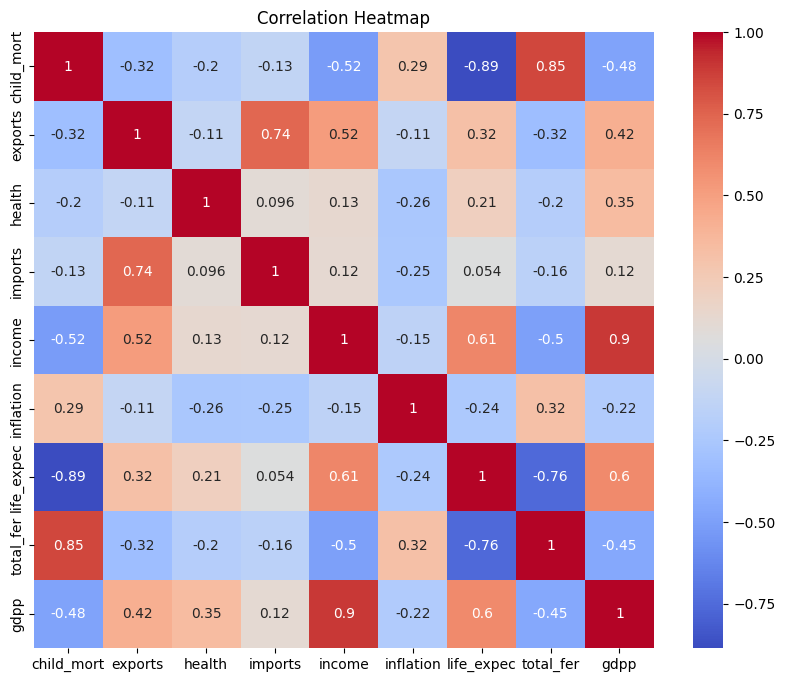

In [70]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_ml.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

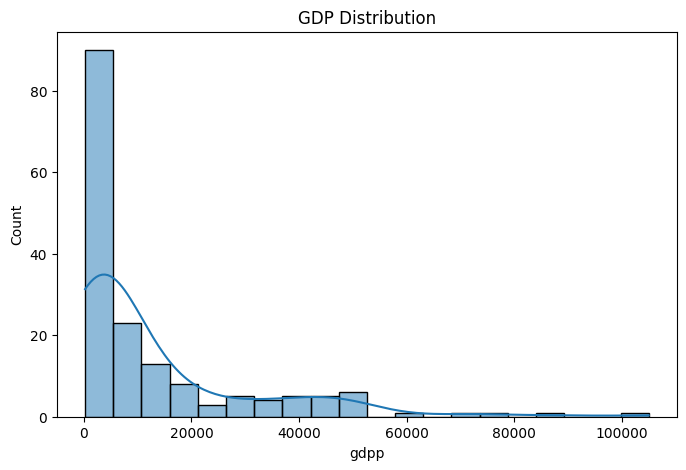

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["gdpp"],
    bins=20,
    kde=True
)

plt.title("GDP Distribution")
plt.show()

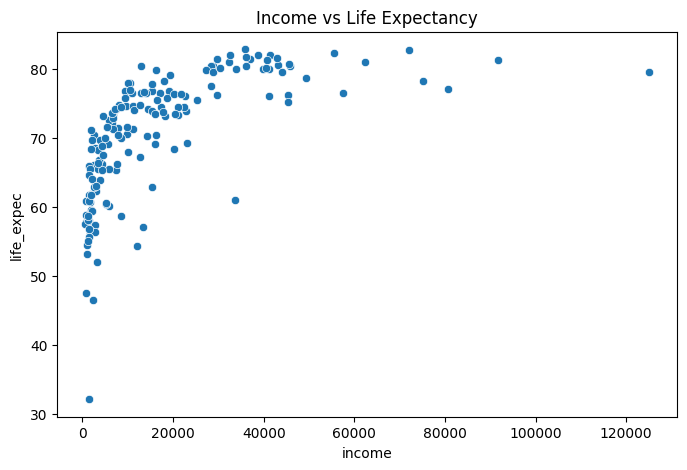

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["income"],
    y=df["life_expec"]
)

plt.title("Income vs Life Expectancy")
plt.show()

# K-Means Clustering

K-Means clustering is used to group countries into different segments based on socio-economic indicators.

In [73]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(scaled_df)

df["KMeans_Cluster"] = kmeans_labels

print("K-Means Clustering Completed")
print(df["KMeans_Cluster"].value_counts())

K-Means Clustering Completed
KMeans_Cluster
0    86
2    45
1    36
Name: count, dtype: int64


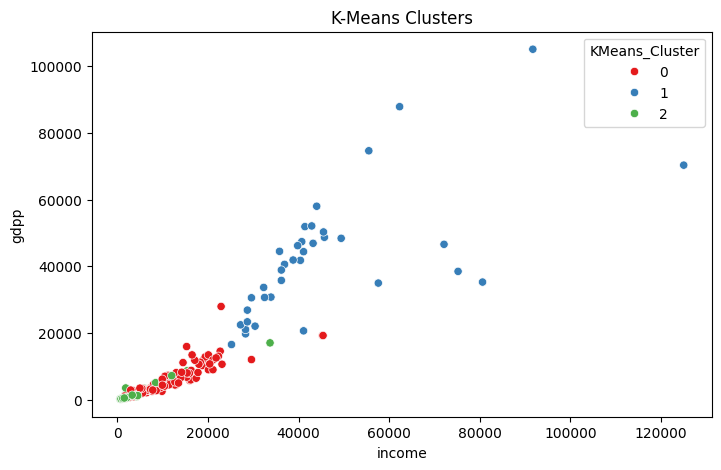

In [74]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["income"],
    y=df["gdpp"],
    hue=df["KMeans_Cluster"],
    palette="Set1"
)

plt.title("K-Means Clusters")
plt.show()

# DBSCAN Clustering

DBSCAN is used to identify dense regions and detect outlier countries.

In [75]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(scaled_df)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Clustering Completed")
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN Clustering Completed
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


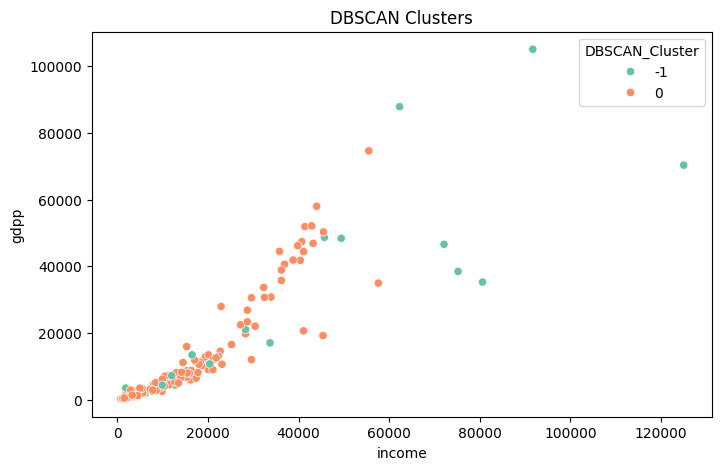

In [76]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["income"],
    y=df["gdpp"],
    hue=df["DBSCAN_Cluster"],
    palette="Set2"
)

plt.title("DBSCAN Clusters")
plt.show()

# Classification Preparation

The K-Means cluster labels are used as target classes for supervised classification models.

In [77]:
X = scaled_df

y = df["KMeans_Cluster"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (167, 9)
Target Shape: (167,)


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Completed")

Train-Test Split Completed


# Random Forest Classification

Random Forest is used to classify countries into customer segments generated by K-Means clustering.

In [79]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [80]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# XGBoost Classification

XGBoost is used as an advanced ensemble learning algorithm for customer segmentation prediction.

In [81]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [82]:
print("XGBoost Accuracy:")
print(accuracy_score(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# Model Evaluation

Performance comparison of Random Forest and XGBoost classifiers.

In [83]:
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_acc, xgb_acc]
})

comparison

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


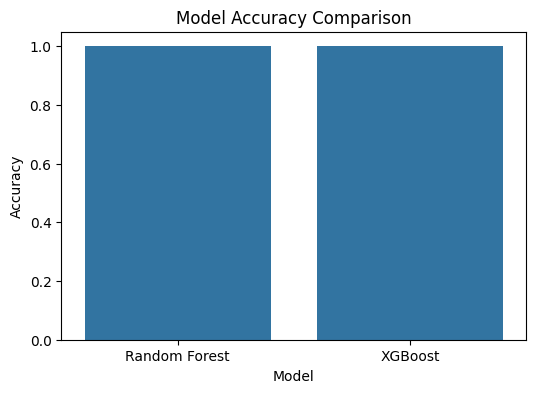

In [84]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Accuracy Comparison")
plt.show()

# Cross Validation

Cross validation helps evaluate model stability and reliability across multiple data splits.

In [85]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.97058824 1.         0.96969697 0.87878788 0.96969697]
Average CV Score:
0.9577540106951872


# Business Insights

Based on clustering and classification analysis:

1. Countries can be grouped into distinct development segments.
2. High-income countries generally show higher GDP and life expectancy.
3. Low-income countries often have higher child mortality rates.
4. K-Means successfully identified meaningful customer/country segments.
5. Random Forest and XGBoost achieved strong classification performance.
6. The developed intelligence system can support data-driven decision making and targeted development strategies.

# Conclusion

This project successfully developed a Customer Intelligence System using Classification, Ensemble Learning, and Clustering techniques.

The workflow included:

- Data Loading
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- K-Means Clustering
- DBSCAN Clustering
- Random Forest Classification
- XGBoost Classification
- Model Evaluation

The results demonstrate that machine learning can effectively segment countries and predict customer intelligence groups using socio-economic indicators.

The project provides meaningful insights that can support strategic planning, resource allocation, and development initiatives.